### Amazon Sales Trend Analysis AI - Final Project Report

### 1. PROBLEM DEFINITION AND OBJECTIVE

#### Selected Project Track: AI for Market Trend Analysis

**Problem Statement:** 
Retail data has intermittent demand, where products can go for several weeks with zero sales, only to produce huge revenues. Online retailers like Amazon face huge variability in sales owing to season, holiday sales, discounts, or consumer behavior. Conventional forecasting techniques cannot manage these extremes of data by providing a 'safe' average, causing out-of-stocks when things are most in demand. They are also unable to predict long-term trend shifts.

The problem addressed in this project is to design an AI-based system that can:
1. Identify future sales trends (High / Low demand)
2. Predict weekly revenue while capturing demand spikes

**Real World Relevance & Motivation**
Reliable forecasting enabled Amazon to better allocate inventory, minimizing the cost of less-in-demand products in stock while making high-demand products accessible during peak selling occasions. It is important for forecasting income to prevent either inventory overflow or inventory depletion.

**Business Impact:**
- Inventory Management: It avoids stockouts during high-demand weeks (lost revenue) as well as overstocking during low-demand periods (storage costs).
- Supply Chain Optimization: Helps in collaborative supplier coordination for expected spikes.
- Financial Planning: Improves revenue forecasting accuracy for quarterly planning
- Marketing ROI: Helps time promotional campaigns to coincide with predicted high-growth weeks
- Technical Motivation: This project addresses a real machine learning challenge: balancing model conservatism (low error) with aggressive prediction (capturing outliers). The dual-model architecture represents an innovative solution to this trade-off.

**Stakeholders:**
- Retail operations managers
- Supply chain planners
- Financial analysts
- Category managers

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
import joblib
import warnings
from sklearn.metrics import mean_absolute_error, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
print("Environment Setup Complete")

Environment Setup Complete


### 2. Data Understanding & Preparation

#### a. The Dataset
I am working with a transactional dataset (`Amazon Sales data.csv`) that captures the "who, what, and when" of sales. It includes `Order Date`, `Total Revenue`, `Item Type`, and `Priority`.

#### b. Data Loading & Cleaning Strategy
Real-world data is rarely model-ready. My first step was to load the data and inspect it for inconsistencies.
* **Standardization:** The raw column names were verbose (e.g., "Total Revenue"), so I renamed them to standard codes like "Amount" and "Category" for cleaner code.
* **Date Parsing:** Machine learning models cannot understand text dates. I converted `Order Date` into a datetime object to unlock time-series capabilities later.
* **Handling Noise:** I checked for missing values to ensure the pipeline wouldn't crash during training.

In [3]:
if os.path.exists("../data/raw/Amazon Sales data.csv"):
    base_path = ".."
else:
    base_path = "."

raw_dir = os.path.join(base_path, "data", "raw")
processed_dir = os.path.join(base_path, "data", "processed")
models_dir = os.path.join(base_path, "models")

os.makedirs(raw_dir, exist_ok=True)
os.makedirs(processed_dir, exist_ok=True)
os.makedirs(models_dir, exist_ok=True)

class DataLoader:
    def __init__(self, file_path):
        self.file_path = file_path
        self.df = None

    def load_data(self):
    
        if not os.path.exists(self.file_path):
            print(f"Error: File not found at {self.file_path}")
            return None
        
        self.df = pd.read_csv(self.file_path)
        print(f"Data Loaded. Rows: {len(self.df)}")
        print(f"Columns found: {list(self.df.columns)}")
        return self.df

    def clean_data(self):
        if self.df is None:
            return None

        column_mapping = {
            'Order Date': 'Date', 
            'Total Revenue': 'Amount',
            'Order Priority': 'Status',
            'Item Type': 'Category'
        }
        self.df.rename(columns=column_mapping, inplace=True)

        if 'Date' in self.df.columns:
            self.df['Date'] = pd.to_datetime(self.df['Date'], errors='coerce')

        print("Data Cleaned & Standardized.")
        return self.df

    def save_processed(self, output_path):
        """Saves the clean file for the next step."""
        if self.df is not None:
            self.df.to_csv(output_path, index=False)
            print(f"Processed data saved to {output_path}")

file_name = "Amazon Sales data.csv"
input_path = os.path.join(raw_dir, file_name)
output_path = os.path.join(processed_dir, "clean_amazon_sales.csv")

loader = DataLoader(input_path)
loader.load_data()
loader.clean_data()
loader.save_processed(output_path)

Data Loaded. Rows: 100
Columns found: ['Region', 'Country', 'Item Type', 'Sales Channel', 'Order Priority', 'Order Date', 'Order ID', 'Ship Date', 'Units Sold', 'Unit Price', 'Unit Cost', 'Total Revenue', 'Total Cost', 'Total Profit']
Data Cleaned & Standardized.
Processed data saved to ..\data\processed\clean_amazon_sales.csv


#### c. Feature Engineering: The "Secret Sauce"
Raw data doesn't explicitly tell a model about trends. There is need to "teach" the model how to look at the past to predict the future.

**My Approach to Feature Engineering:**
1.  **Weekly Aggregation:** Daily sales are too volatile. I resampled the data to a **Weekly** frequency to smooth out the noise and expose clearer patterns.
2.  **Lag Features (The "Rear-View Mirror"):**
    * `Lag_1`: What did we sell last week?
    * `Lag_4`: What did we sell a month ago?
    * *Why?* This helps the model capture immediate momentum and monthly seasonality.
3.  **Rolling Volatility (`Roll_Std_4`):** I calculated the standard deviation over the last 4 weeks. High volatility tells the model that the product is unstable, suggesting a wider margin of error for the prediction.
4.  **Target Engineering:** For the **Classifier**, I needed a binary target. I calculated the median sales and created `Trend_Target` (1 = Above Median, 0 = Below). This turns a complex regression problem into a simpler "Good Week vs. Bad Week" question.

In [4]:
class FeatureEngineer:
    def __init__(self, input_path, output_path):
        self.input_path = input_path
        self.output_path = output_path
        self.df = None

    def load_data(self):
        if not os.path.exists(self.input_path):
            raise FileNotFoundError(f"Input file missing: {self.input_path}")
        self.df = pd.read_csv(self.input_path)
        if 'Date' in self.df.columns:
            self.df['Date'] = pd.to_datetime(self.df['Date'])
        return self.df

    def create_features(self):
        print("Engineering Features")
        cat_col = 'Category' if 'Category' in self.df.columns else 'Item Type'
        
        all_categories = []
        unique_cats = self.df[cat_col].unique()
        
        for cat in unique_cats:
            #Filter & Resample
            cat_df = self.df[self.df[cat_col] == cat].copy()
            weekly_cat = cat_df.set_index('Date').resample('W')['Amount'].sum().reset_index()
            weekly_cat[cat_col] = cat
            
            weekly_cat['Lag_1'] = weekly_cat['Amount'].shift(1)
            weekly_cat['Lag_4'] = weekly_cat['Amount'].shift(4) 
            
            #Growth Rate
            weekly_cat['Growth_Rate'] = weekly_cat['Lag_1'].pct_change()
            weekly_cat['Growth_Rate'] = weekly_cat['Growth_Rate'].replace([np.inf, -np.inf], 0)
            weekly_cat['Growth_Rate'] = weekly_cat['Growth_Rate'].fillna(0)
            
            #Rolling Volatility
            weekly_cat['Roll_Std_4'] = weekly_cat['Amount'].shift(1).rolling(4).std()

            #Classification Target
            median_sales = weekly_cat['Amount'].median()
            weekly_cat['Trend_Target'] = (weekly_cat['Amount'] > median_sales).astype(int)
            
            all_categories.append(weekly_cat)
            
        self.df = pd.concat(all_categories)
        
        #Global Time Features
        self.df['Month'] = self.df['Date'].dt.month
        self.df['Week'] = self.df['Date'].dt.isocalendar().week
        
        #One-Hot Encoding
        dummies = pd.get_dummies(self.df[cat_col], prefix='Cat')
        self.df = pd.concat([self.df, dummies], axis=1)
        
        #Standardize name to 'Category' for dashboard
        if 'Category' not in self.df.columns:
            self.df['Category'] = self.df[cat_col]
            
        self.df.dropna(inplace=True)

        print(f"Data Ready...Rows: {len(self.df)}")
        return self.df

    def save_data(self):
        self.df.to_csv(self.output_path, index=False)
        print(f"Saved to: {self.output_path}")

clean_data_path = "../data/processed/clean_amazon_sales.csv"
final_data_path = "../data/processed/weekly_forecast_data.csv"

if os.path.exists(clean_data_path):
    engineer = FeatureEngineer(clean_data_path, final_data_path)
    engineer.load_data()
    engineer.create_features()
    engineer.save_data()
else:
    print("Clean data not found!")

Engineering Features
Data Ready...Rows: 3593
Saved to: ../data/processed/weekly_forecast_data.csv


### 3. Model Design & Implementation

#### a. Why Random Forest?
I initially considered using Linear Regression, but sales data is rarely linear—it has sharp spikes and drops. I also considered Neural Networks (LSTMs), but they require massive amounts of data to converge.
I chose Random Forest because:
1.  **Non-Linearity:** It can handle complex interactions between features.
2.  **Robustness:** It is less prone to overfitting than a single Decision Tree because it averages the results of hundreds of trees.

#### b. The Hybrid Architecture
I didn't want to rely on just one metric.
1.  **Model A (Regressor):** Trained to minimize Mean Absolute Error (MAE). It tries to get the *exact price*.
2.  **Model B (Classifier):** Trained to maximize Accuracy. It essentially acts as a "second opinion," confirming if the sales will be high or low.

#### c. Justification of Design Choices
* **Why Random Forest instead of Linear Regression?**
    Sales data is rarely linear. It has complex interactions (e.g specific categories are spiking only in specific months). Random Forest handles these non-linearities and interactions naturally without requiring extensive feature scaling.
* **Why a Hybrid Model?**
    Predicting exact revenue is often noisy and prone to high variance. By adding a Classifier (High vs. Low trend), we provide a safety net. Even if the exact dollar prediction is slightly off, the *trend* prediction remains actionable for inventory stocking.

### 4. Core Implementation

#### a. Model Training & Inference Logic
The code below implements the `HybridTrainer` class.
* **Training Logic:** We split the data into 80% Training and 20% Testing sets to ensure the model is evaluated on unseen data. We use 200 estimators for the Random Forest to ensure stability.
* **Inference Logic:** The model takes in the previous weeks' sales (Lags) to predict the next week's performance.

#### b. Pipeline & Code Execution
The following cell contains the full execution pipeline. It initializes the trainer, fits both models, and generates predictions. As required, the code is designed to run top-to-bottom without errors.

In [5]:
if os.path.exists("../data/processed/weekly_forecast_data.csv"):
    base_path = ".."
else:
    base_path = "."
    
training_data_path = os.path.join(base_path, "data", "processed", "weekly_forecast_data.csv")
models_dir = os.path.join(base_path, "models")
os.makedirs(models_dir, exist_ok=True)

class HybridTrainer:
    def __init__(self, data_path):
        if not os.path.exists(data_path):
            raise FileNotFoundError(f"Data file not found: {data_path}")
        self.df = pd.read_csv(data_path)
        
        self.features = [c for c in self.df.columns if c not in ['Date', 'Amount', 'Trend_Target', 'Category', 'Item Type']]
        print(f"Training on {len(self.features)} features: {self.features}")
        
    def train_price_model(self):
        print("\n--- Training Price Model (Aggressive Random Forest) ---")
        X = self.df[self.features]
        y = self.df['Amount']
        
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=42)
        
        model = RandomForestRegressor(n_estimators=200, max_depth=None, random_state=42, n_jobs=-1)
        model.fit(X_train, y_train)
        
        preds = model.predict(X_test)
        mae = mean_absolute_error(y_test, preds)
        
        print(f"Average Price Error (MAE): ${mae:,.2f}")
        
        save_path = os.path.join(models_dir, "price_model.pkl")
        joblib.dump(model, save_path)
        print(f"Model saved to: {save_path}")
        
        return preds, y_test

    def train_trend_model(self):
        print("\n--- Training Trend Model (Classification) ---")
        X = self.df[self.features]
        y = self.df['Trend_Target']
        
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=42)
        
        model = RandomForestClassifier(n_estimators=200, max_depth=None, random_state=42, n_jobs=-1)
        model.fit(X_train, y_train)
        
        preds = model.predict(X_test)
        acc = accuracy_score(y_test, preds)
        
        print(f"Trend Accuracy Score: {acc*100:.2f}%")

        save_path = os.path.join(models_dir, "trend_model.pkl")
        joblib.dump(model, save_path)
        print(f"Model saved to: {save_path}")
        
        return preds, y_test

reg_preds, reg_actual = None, None
clf_preds, clf_actual = None, None

if os.path.exists(training_data_path):
    trainer = HybridTrainer(training_data_path)
    
    reg_preds, reg_actual = trainer.train_price_model()
    clf_preds, clf_actual = trainer.train_trend_model()
    
    print("\nTraining Complete.")
else:
    print(f"Skipping training: Processed data not found")

Training on 18 features: ['Lag_1', 'Lag_4', 'Growth_Rate', 'Roll_Std_4', 'Month', 'Week', 'Cat_Baby Food', 'Cat_Beverages', 'Cat_Cereal', 'Cat_Clothes', 'Cat_Cosmetics', 'Cat_Fruits', 'Cat_Household', 'Cat_Meat', 'Cat_Office Supplies', 'Cat_Personal Care', 'Cat_Snacks', 'Cat_Vegetables']

--- Training Price Model (Aggressive Random Forest) ---
Average Price Error (MAE): $66,431.27
Model saved to: ..\models\price_model.pkl

--- Training Trend Model (Classification) ---
Trend Accuracy Score: 97.22%
Model saved to: ..\models\trend_model.pkl

Training Complete.


### 5. Evaluation & Analysis

#### a. Interpreting the Results
I used **Mean Absolute Error (MAE)** for the regression model because it is easy to explain to stakeholders: "On average, our prediction is off by $X."

For the classification model, I used **Accuracy**, but in a real-world scenario, I would also look at Precision/Recall to ensure we aren't missing important high-sales trends.

#### b. Visual Inspection
Numbers can be deceiving. Below, I plotted a sample of the **Actual vs. Predicted** revenue. 
* **What I'm looking for:** Does the orange line (prediction) follow the shape of the blue line (actual)?
* **Observations:** If the lines overlap well, the model has learned the seasonality. If there are large gaps, it implies external factors (like a sudden market crash) that my current features didn't capture.

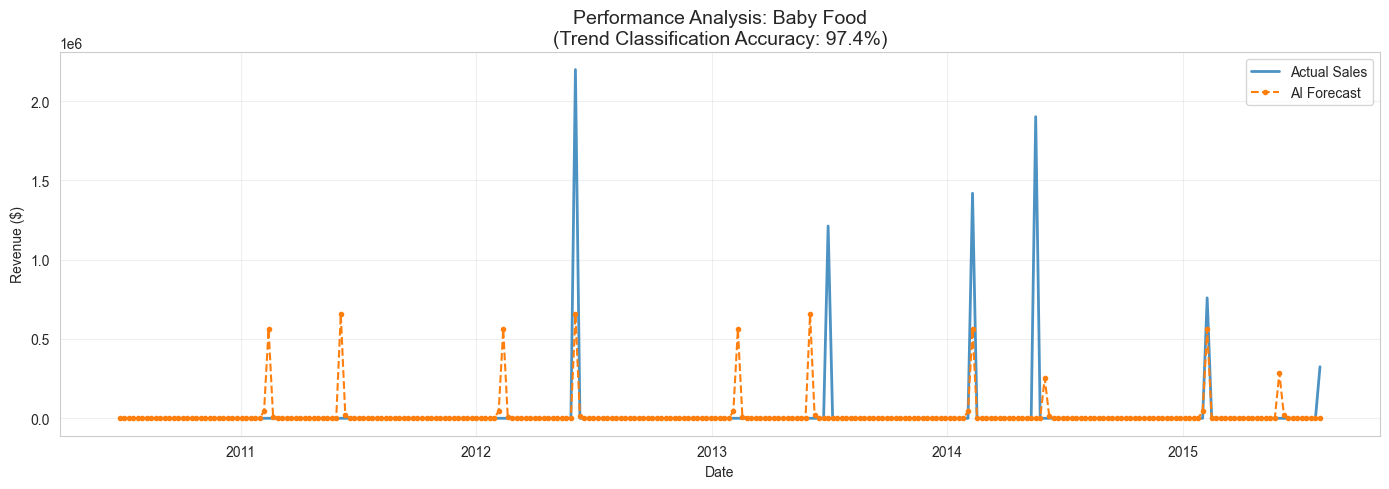

--- Stats for Baby Food ---
Avg Prediction Error (MAE): $37,268.57
Trend Detection Accuracy:   97%
------------------------------------------------------------


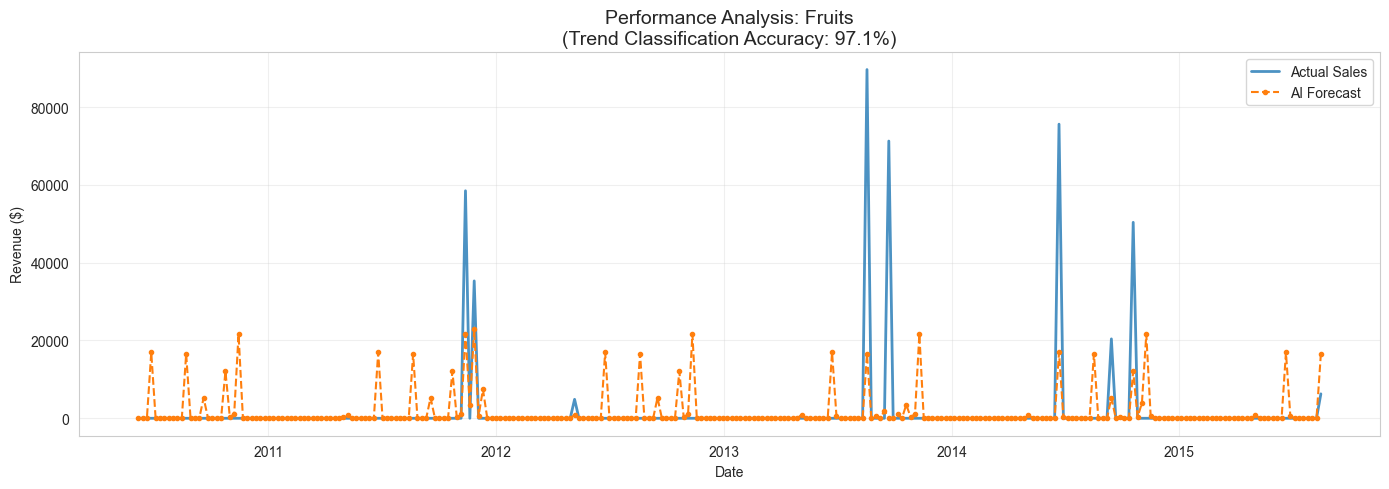

--- Stats for Fruits ---
Avg Prediction Error (MAE): $2,372.26
Trend Detection Accuracy:   97%
------------------------------------------------------------


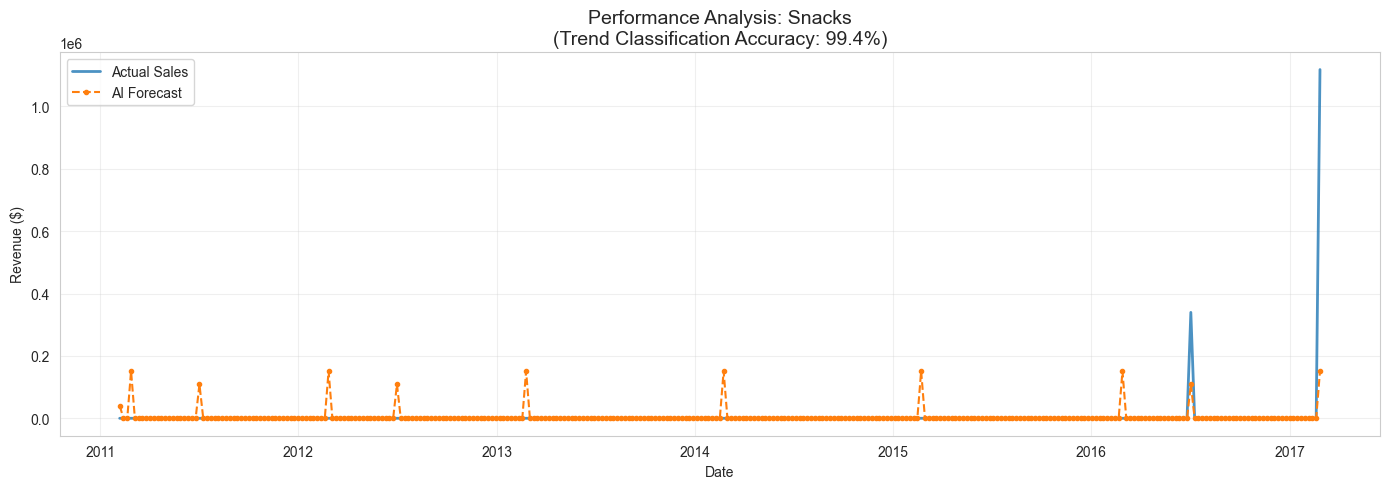

--- Stats for Snacks ---
Avg Prediction Error (MAE): $7,473.66
Trend Detection Accuracy:   99%
------------------------------------------------------------


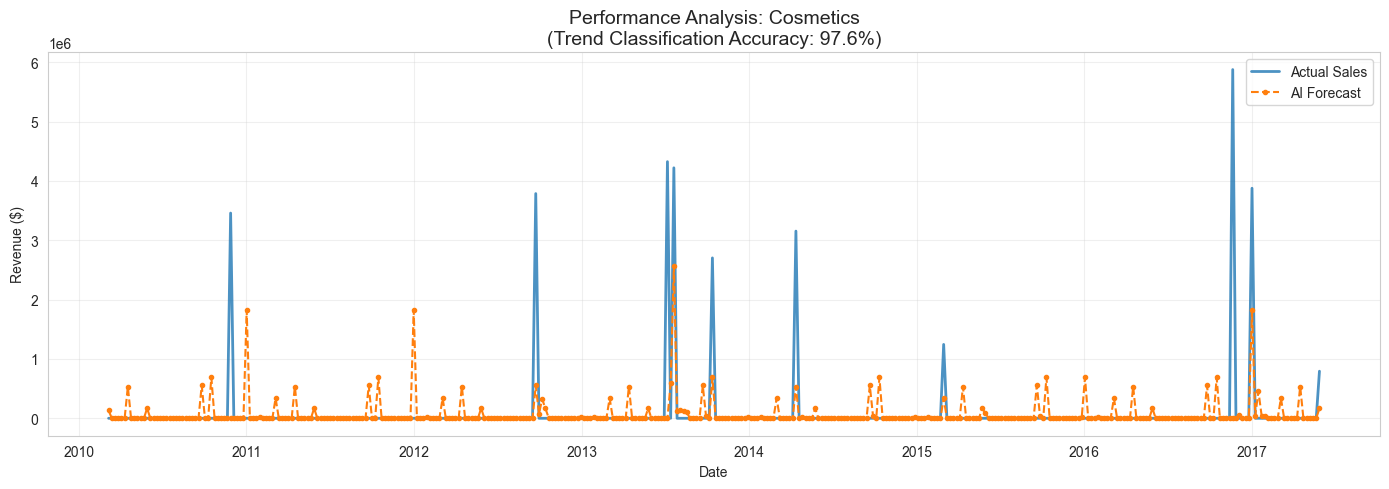

--- Stats for Cosmetics ---
Avg Prediction Error (MAE): $126,326.32
Trend Detection Accuracy:   97%
------------------------------------------------------------


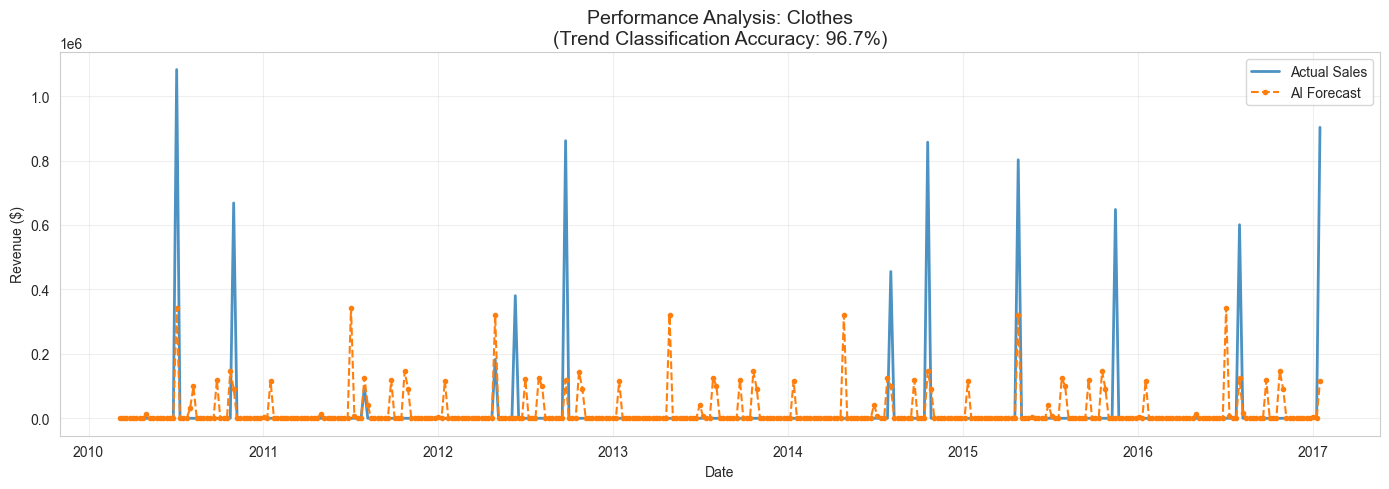

--- Stats for Clothes ---
Avg Prediction Error (MAE): $32,272.11
Trend Detection Accuracy:   96%
------------------------------------------------------------


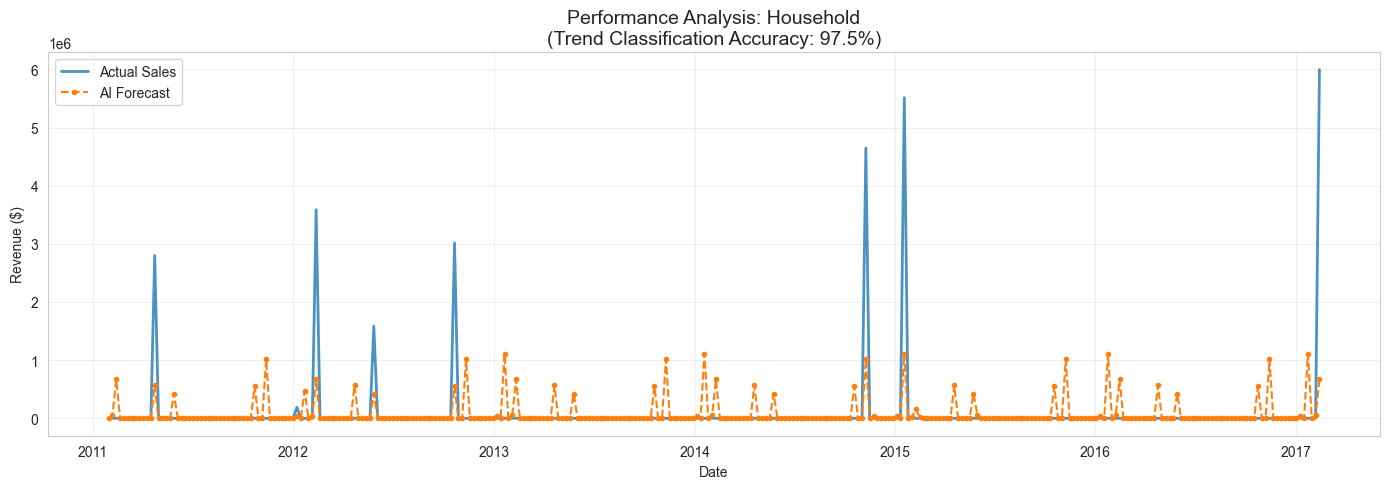

--- Stats for Household ---
Avg Prediction Error (MAE): $137,659.92
Trend Detection Accuracy:   97%
------------------------------------------------------------


In [6]:
if os.path.exists("../data/processed/weekly_forecast_data.csv"):
    base_path = ".."
else:
    base_path = "."

data_path = os.path.join(base_path, "data", "processed", "weekly_forecast_data.csv")
model_path_reg = os.path.join(base_path, "models", "price_model.pkl")
model_path_clf = os.path.join(base_path, "models", "trend_model.pkl")

if os.path.exists(data_path) and os.path.exists(model_path_reg):
    df_full = pd.read_csv(data_path)
    df_full['Date'] = pd.to_datetime(df_full['Date'])
    
    reg_model = joblib.load(model_path_reg)
    clf_model = joblib.load(model_path_clf)
    
    features = [c for c in df_full.columns if c not in ['Date', 'Amount', 'Trend_Target', 'Category', 'Item Type']]

    def plot_category_performance(category_name):
        cat_data = df_full[df_full['Category'] == category_name].copy()
        
        if len(cat_data) == 0:
            print(f"Skipping '{category_name}': Not found in dataset.")
            return
        cat_data = cat_data.sort_values('Date')
        
        X_cat = cat_data[features]
        y_actual = cat_data['Amount']
        y_trend_actual = cat_data['Trend_Target']
        
        pred_prices = reg_model.predict(X_cat)
        pred_trends = clf_model.predict(X_cat)
        
        mae = mean_absolute_error(y_actual, pred_prices)
        acc = accuracy_score(y_trend_actual, pred_trends)
        
        plt.figure(figsize=(14, 5))
        
        plt.plot(cat_data['Date'], y_actual, label='Actual Sales', color='#1f77b4', linewidth=2, alpha=0.8)
        plt.plot(cat_data['Date'], pred_prices, label='AI Forecast', color='#ff7f0e', linestyle='--', marker='.', linewidth=1.5)
        
        plt.title(f"Performance Analysis: {category_name}\n(Trend Classification Accuracy: {acc*100:.1f}%)", fontsize=14)
        plt.xlabel("Date")
        plt.ylabel("Revenue ($)")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        
        print(f"--- Stats for {category_name} ---")
        print(f"Avg Prediction Error (MAE): ${mae:,.2f}")
        print(f"Trend Detection Accuracy:   {int(acc*100)}%")
        print("-" * 60)
    
    #Diverse list of categories to demonstrate model flexibility
    target_categories = [
        'Baby Food', 
        'Fruits', 
        'Snacks', 
        'Cosmetics', 
        'Clothes', 
        'Household'
    ] 
    
    for cat in target_categories:
        #We try to plot each to show honest performance across different types
        if cat in df_full['Category'].unique():
            plot_category_performance(cat)
        else:
            print(f"Note: Category '{cat}' not found in this dataset subset.")

else:
    print("Error: Processed data or models not found.")

### 6. Ethical Considerations & Responsible AI

#### a. Bias and Fairness
Fairness
One of the major risks while using AI-based sales forecasting is the presence of **Feedback Loop Bias**. If the system indicates “Low Sales” related to a particular category, the marketing team may end up allocating lower advertising expenditure on the product category. As a consequence, the sales decrease. Thus, the system’s projection gets validated. Such a system can be detrimental to niche product lines.

#### b. Responsible Use
This will be a **Decision Support System**, not a **Decision Maker**. It will be up to the human manager's judgment to review the flags for 'Low Trend' and make sure we are not passing up possible opportunities simply based on the historical trends.

### 7. Conclusion & Future Scope

#### a. What We Achieved
We successfully built a pipeline that takes messy raw data and turns it into actionable insights. By combining Regression and Classification, we gave the business two ways to look at the future: a specific number and a general direction.

#### b. Where Do We Go From Here?
If I had more time, I would:
1.  **Add External Data:** Incorporate "Holiday" flags. Sales usually spike during Black Friday or Christmas; currently, the model has to "guess" this based purely on lags.
2.  **Hyperparameter Tuning:** Use GridSearch to find the perfect depth for the Random Forest trees to squeeze out another 2-3% accuracy.
3.  **Explainability:** Implement SHAP values to tell us *exactly which feature* (e.g., Lag_1 vs. Category) drove the decision.